In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

In [3]:
# laoding the dataset
data = pd.read_csv('Energy data.csv')
data

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,11-01-2016 17:00,60,30,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.000000,...,17.033333,45.5300,6.60,733.5,92.000000,7.000000,63.000000,5.3,13.275433,13.275433
1,11-01-2016 17:10,60,30,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.000000,...,17.066667,45.5600,6.48,733.6,92.000000,6.666667,59.166667,5.2,18.606195,18.606195
2,11-01-2016 17:20,50,30,19.890000,46.300000,19.200000,44.626667,19.790000,44.933333,18.926667,...,17.000000,45.5000,6.37,733.7,92.000000,6.333333,55.333333,5.1,28.642668,28.642668
3,11-01-2016 17:30,50,40,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.890000,...,17.000000,45.4000,6.25,733.8,92.000000,6.000000,51.500000,5.0,45.410390,45.410390
4,11-01-2016 17:40,60,40,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.890000,...,17.000000,45.4000,6.13,733.9,92.000000,5.666667,47.666667,4.9,10.084097,10.084097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19730,27-05-2016 17:20,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.700000,...,23.200000,46.7900,22.70,755.2,55.666667,3.333333,23.666667,13.3,43.096812,43.096812
19731,27-05-2016 17:30,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.700000,...,23.200000,46.7900,22.60,755.2,56.000000,3.500000,24.500000,13.3,49.282940,49.282940
19732,27-05-2016 17:40,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.700000,...,23.200000,46.7900,22.50,755.2,56.333333,3.666667,25.333333,13.3,29.199117,29.199117
19733,27-05-2016 17:50,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.700000,...,23.200000,46.8175,22.30,755.2,56.666667,3.833333,26.166667,13.2,6.322784,6.322784


## Data Preprocessing

#### Data Preprocessing: Handle missing values, convert date/time features, and normalize numerical data.

In [8]:
# Converting data into dataframe
df = pd.DataFrame(data)

In [10]:
# Dropping 'Date' column
df = df.drop(columns=['date','lights'])

In [12]:
df

,Appliances,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,60,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.000000,45.566667,17.166667,...,17.033333,45.5300,6.60,733.5,92.000000,7.000000,63.000000,5.3,13.275433,13.275433
1,60,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.000000,45.992500,17.166667,...,17.066667,45.5600,6.48,733.6,92.000000,6.666667,59.166667,5.2,18.606195,18.606195
2,50,19.890000,46.300000,19.200000,44.626667,19.790000,44.933333,18.926667,45.890000,17.166667,...,17.000000,45.5000,6.37,733.7,92.000000,6.333333,55.333333,5.1,28.642668,28.642668
3,50,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.890000,45.723333,17.166667,...,17.000000,45.4000,6.25,733.8,92.000000,6.000000,51.500000,5.0,45.410390,45.410390
4,60,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.890000,45.530000,17.200000,...,17.000000,45.4000,6.13,733.9,92.000000,5.666667,47.666667,4.9,10.084097,10.084097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19730,100,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.700000,45.590000,23.200000,...,23.200000,46.7900,22.70,755.2,55.666667,3.333333,23.666667,13.3,43.096812,43.096812
19731,90,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.700000,45.590000,23.230000,...,23.200000,46.7900,22.60,755.2,56.000000,3.500000,24.500000,13.3,49.282940,49.282940
19732,270,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.700000,45.730000,23.230000,...,23.200000,46.7900,22.50,755.2,56.333333,3.666667,25.333333,13.3,29.199117,29.199117
19733,420,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.700000,45.790000,23.200000,...,23.200000,46.8175,22.30,755.2,56.666667,3.833333,26.166667,13.2,6.322784,6.322784


## Basic statistics and EDA

#### Exploratory Data Analysis (EDA): Visualize feature distributions and correlations to understand relationships with appliance energy usage.

In [16]:
df.head()    #shows top 5 rows

,Appliances,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,60,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,...,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,60,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,...,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,50,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,...,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,50,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,...,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,60,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,...,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [18]:
df.tail()    #shows bottom 5 rows

,Appliances,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
19730,100,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.7,45.590000,23.20,...,23.2,46.7900,22.7,755.2,55.666667,3.333333,23.666667,13.3,43.096812,43.096812
19731,90,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.7,45.590000,23.23,...,23.2,46.7900,22.6,755.2,56.000000,3.500000,24.500000,13.3,49.282940,49.282940
19732,270,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.7,45.730000,23.23,...,23.2,46.7900,22.5,755.2,56.333333,3.666667,25.333333,13.3,29.199117,29.199117
19733,420,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.7,45.790000,23.20,...,23.2,46.8175,22.3,755.2,56.666667,3.833333,26.166667,13.2,6.322784,6.322784
19734,430,25.500000,46.600000,25.264286,42.971429,26.823333,41.156667,24.7,45.963333,23.20,...,23.2,46.8450,22.2,755.2,57.000000,4.000000,27.000000,13.2,34.118851,34.118851


In [20]:
df.info()   # shows structure and contents of dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 27 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   19735 non-null  int64  
 1   T1           19735 non-null  float64
 2   RH_1         19735 non-null  float64
 3   T2           19735 non-null  float64
 4   RH_2         19735 non-null  float64
 5   T3           19735 non-null  float64
 6   RH_3         19735 non-null  float64
 7   T4           19735 non-null  float64
 8   RH_4         19735 non-null  float64
 9   T5           19735 non-null  float64
 10  RH_5         19735 non-null  float64
 11  T6           19735 non-null  float64
 12  RH_6         19735 non-null  float64
 13  T7           19735 non-null  float64
 14  RH_7         19735 non-null  float64
 15  T8           19735 non-null  float64
 16  RH_8         19735 non-null  float64
 17  T9           19735 non-null  float64
 18  RH_9         19735 non-null  float64
 19  T_ou

In [22]:
df.isnull().sum()    #checking for null values

Appliances     0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [24]:
df.describe()     # descriptive statistics for all numeric columns in the DataFrame

,Appliances,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,19.592106,...,19.485828,41.552401,7.412580,755.522602,79.750418,4.039752,38.330834,3.760995,24.988033,24.988033
std,102.524891,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,1.844623,...,2.014712,4.151497,5.318464,7.399441,14.901088,2.451221,11.794719,4.195248,14.496634,14.496634
min,10.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,15.330000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,18.277500,...,18.000000,38.500000,3.670000,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,19.390000,...,19.390000,40.900000,6.920000,756.100000,83.666667,3.666667,40.000000,3.430000,24.897653,24.897653
75%,100.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,20.619643,...,20.600000,44.338095,10.400000,760.933333,91.666667,5.500000,40.000000,6.570000,37.583769,37.583769
max,1080.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,25.795000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [26]:
df.duplicated().sum()     # checking for duplicate rows

0

In [28]:
# select only numeric columns from the DataFrame

num_columns = df.select_dtypes(include = 'number')
num_columns

,Appliances,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,60,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.000000,45.566667,17.166667,...,17.033333,45.5300,6.60,733.5,92.000000,7.000000,63.000000,5.3,13.275433,13.275433
1,60,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.000000,45.992500,17.166667,...,17.066667,45.5600,6.48,733.6,92.000000,6.666667,59.166667,5.2,18.606195,18.606195
2,50,19.890000,46.300000,19.200000,44.626667,19.790000,44.933333,18.926667,45.890000,17.166667,...,17.000000,45.5000,6.37,733.7,92.000000,6.333333,55.333333,5.1,28.642668,28.642668
3,50,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.890000,45.723333,17.166667,...,17.000000,45.4000,6.25,733.8,92.000000,6.000000,51.500000,5.0,45.410390,45.410390
4,60,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.890000,45.530000,17.200000,...,17.000000,45.4000,6.13,733.9,92.000000,5.666667,47.666667,4.9,10.084097,10.084097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19730,100,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.700000,45.590000,23.200000,...,23.200000,46.7900,22.70,755.2,55.666667,3.333333,23.666667,13.3,43.096812,43.096812
19731,90,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.700000,45.590000,23.230000,...,23.200000,46.7900,22.60,755.2,56.000000,3.500000,24.500000,13.3,49.282940,49.282940
19732,270,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.700000,45.730000,23.230000,...,23.200000,46.7900,22.50,755.2,56.333333,3.666667,25.333333,13.3,29.199117,29.199117
19733,420,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.700000,45.790000,23.200000,...,23.200000,46.8175,22.30,755.2,56.666667,3.833333,26.166667,13.2,6.322784,6.322784


## Outlier Detection and Treatment

#### The Interquartile Range (IQR) method helps detect outliers:
#### IQR = Q3 - Q1

#### Outliers lie below Q1 - 1.5IQR or above Q3 + 1.5IQR
#### These outliers are removed or capped to improve model robustness.



<Axes: >

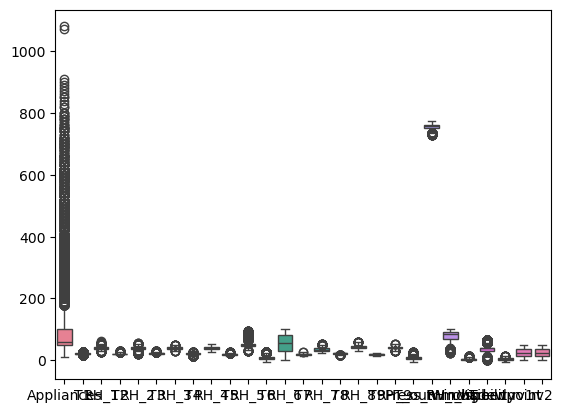

In [32]:
# plotting boxplots for all numeric columns in the DataFrame

sns.boxplot(data = df)

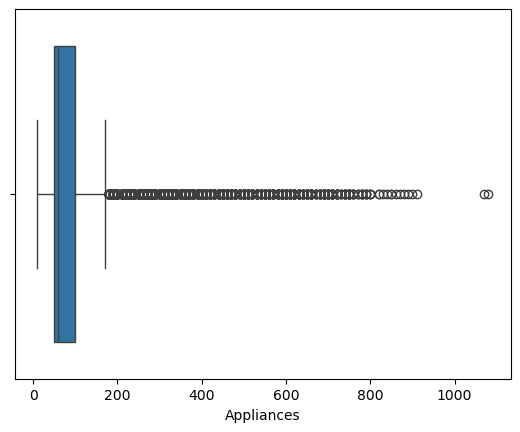

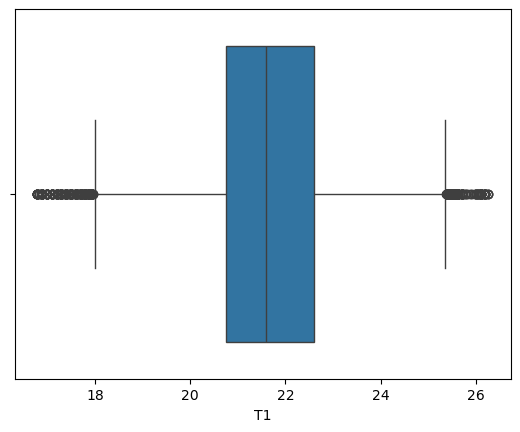

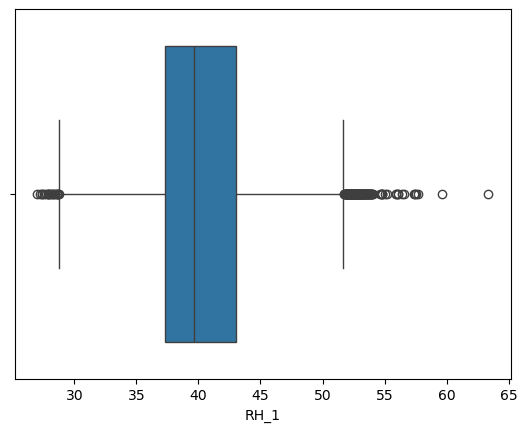

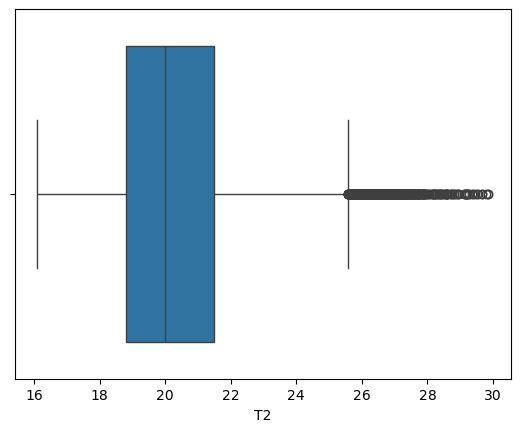

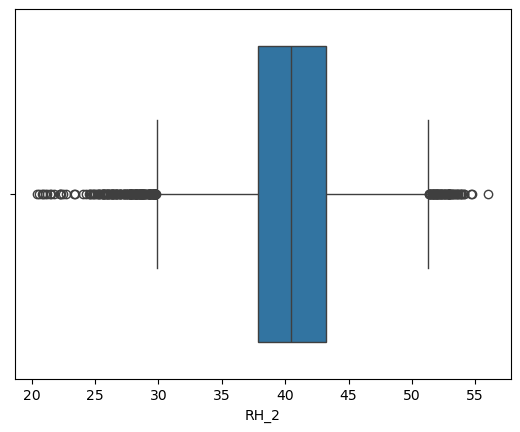

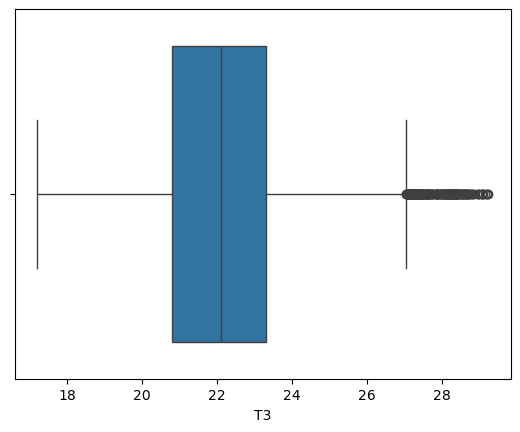

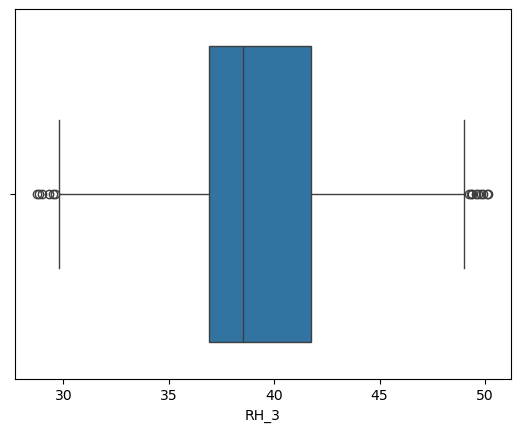

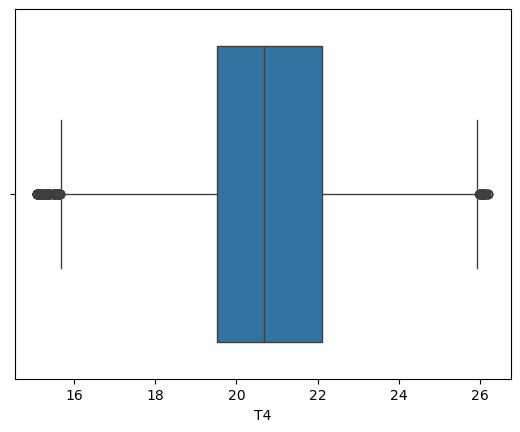

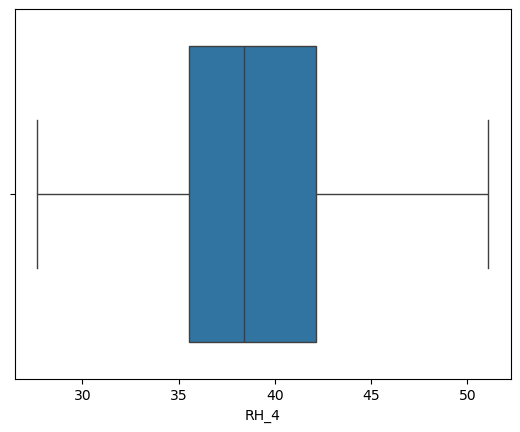

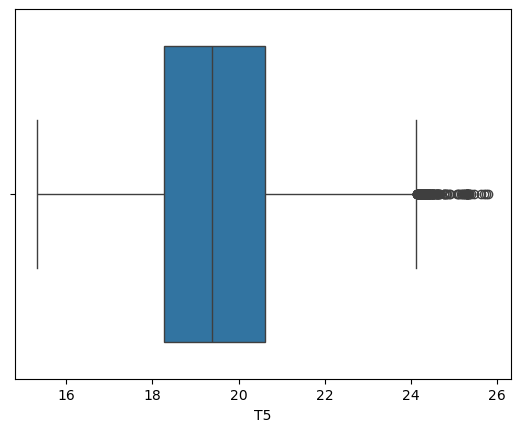

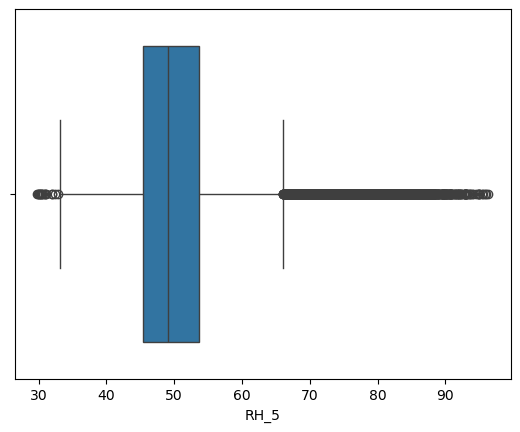

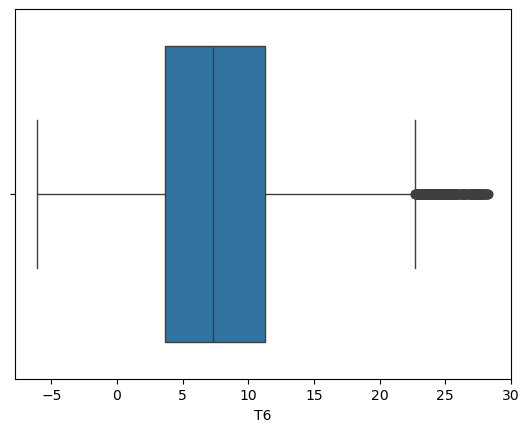

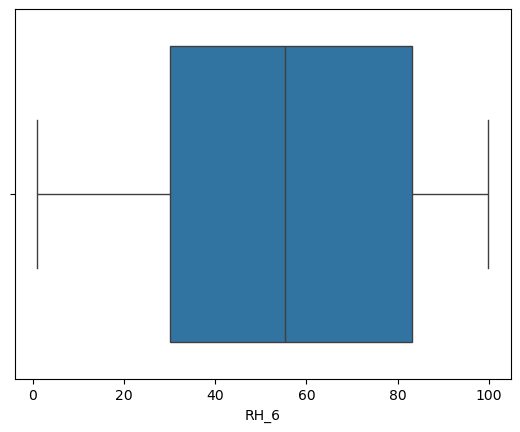

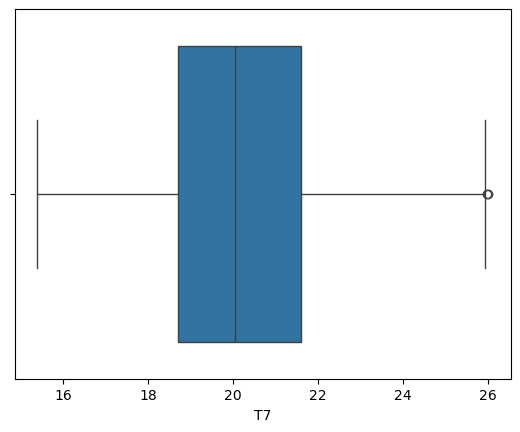

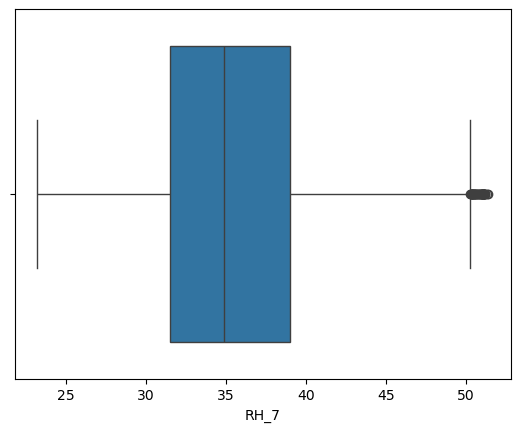

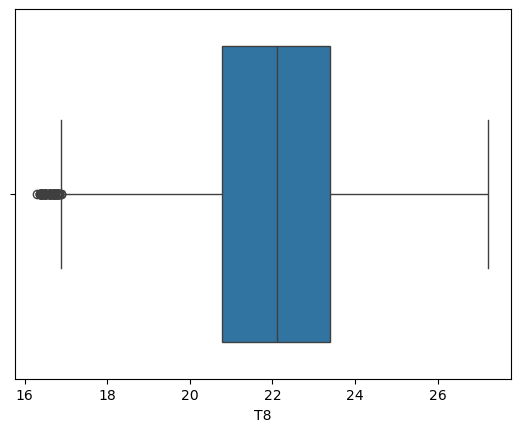

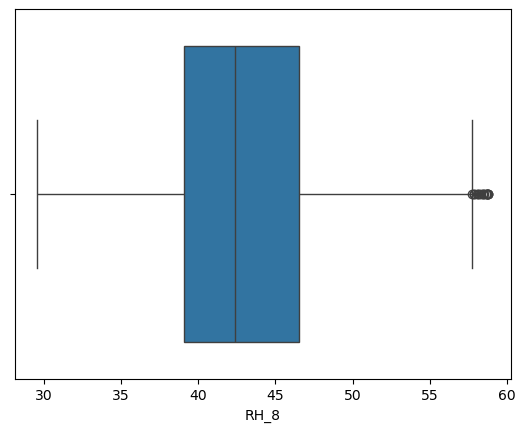

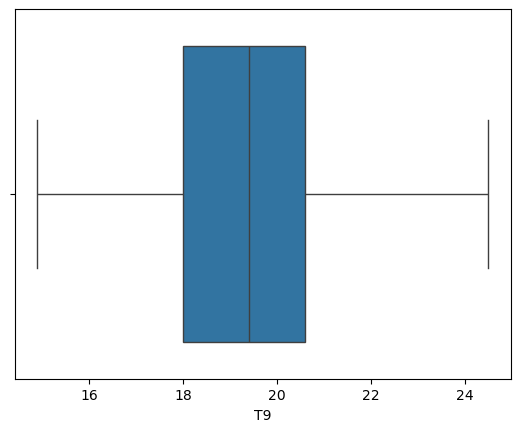

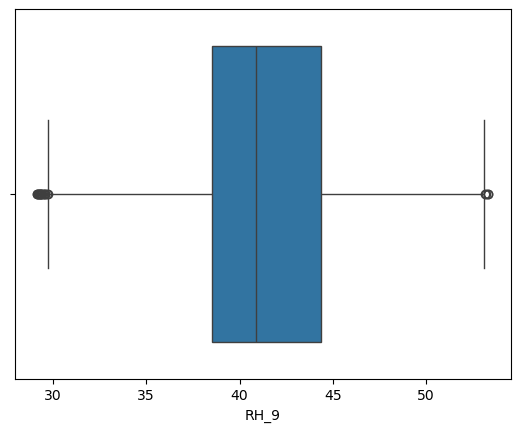

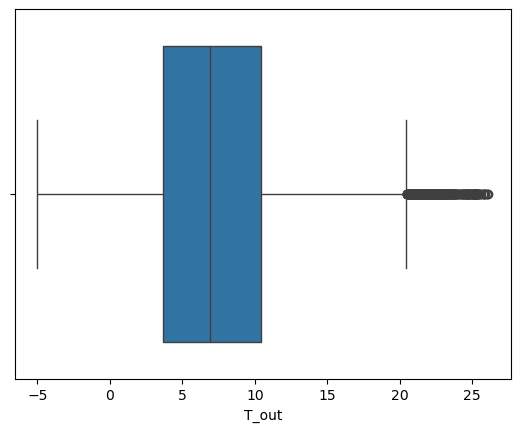

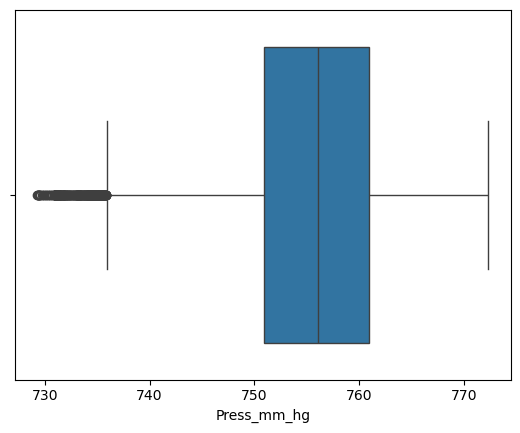

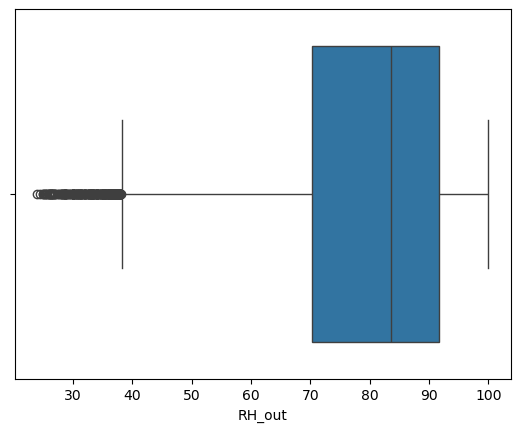

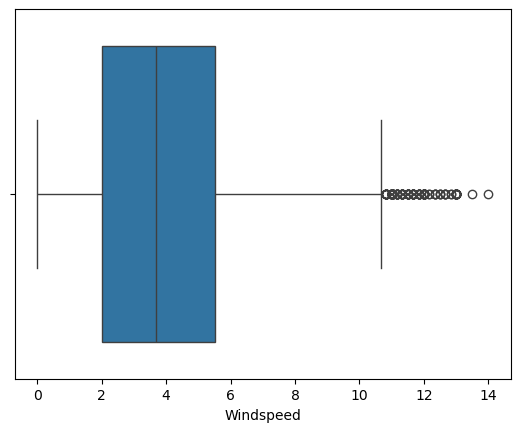

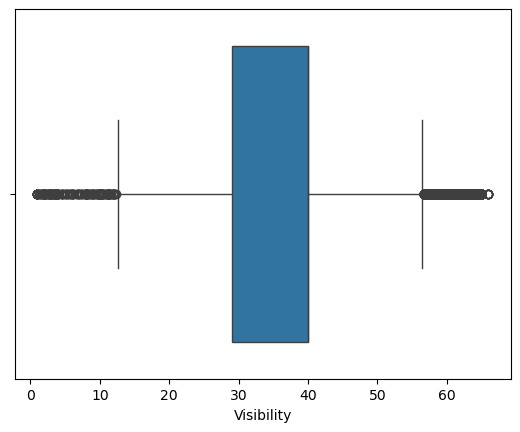

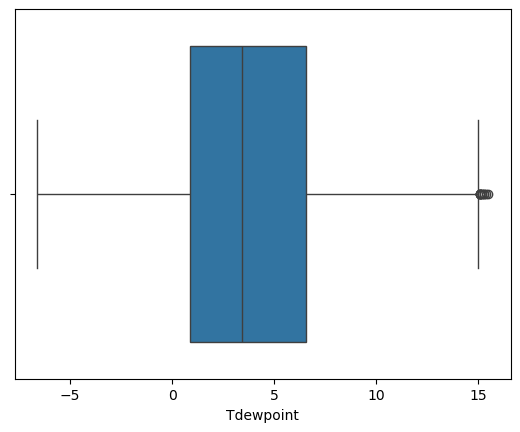

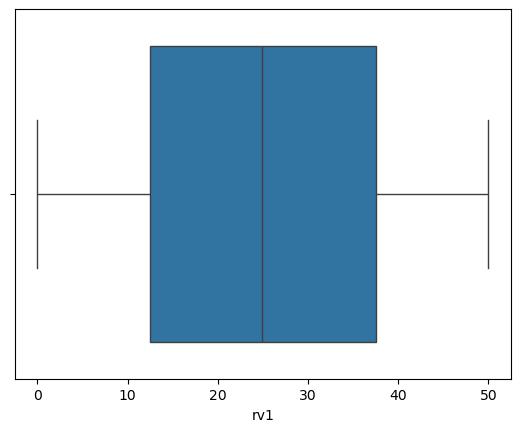

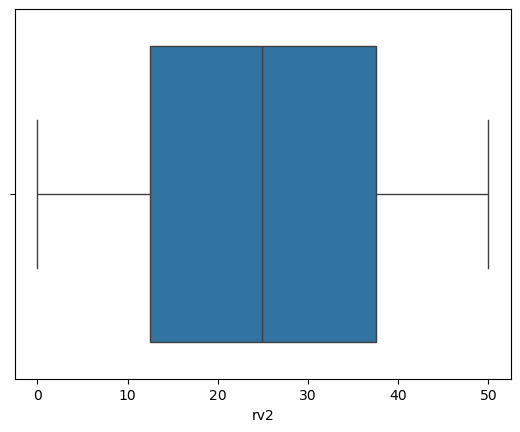

In [33]:
# generating individual boxplots for each numeric column

for i in num_columns.columns:
    sns.boxplot(data=df,x=i)
    plt.show()

In [35]:
# IQR Method
def outliers(df):
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - (1.5 * IQR)
        upper = Q3 + (1.5 * IQR)

        # Capping
        df[col] = df[col].apply(lambda x: lower if x < lower else upper if x > upper else x)

    return df

In [36]:
df_new = outliers(df)    # new dataframe

In [40]:
df_new.head()

,Appliances,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,60.0,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,...,17.033333,45.53,6.60,735.933333,92.0,7.000000,56.500000,5.3,13.275433,13.275433
1,60.0,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,...,17.066667,45.56,6.48,735.933333,92.0,6.666667,56.500000,5.2,18.606195,18.606195
2,50.0,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,...,17.000000,45.50,6.37,735.933333,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,50.0,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,...,17.000000,45.40,6.25,735.933333,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,60.0,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,...,17.000000,45.40,6.13,735.933333,92.0,5.666667,47.666667,4.9,10.084097,10.084097


<Axes: >

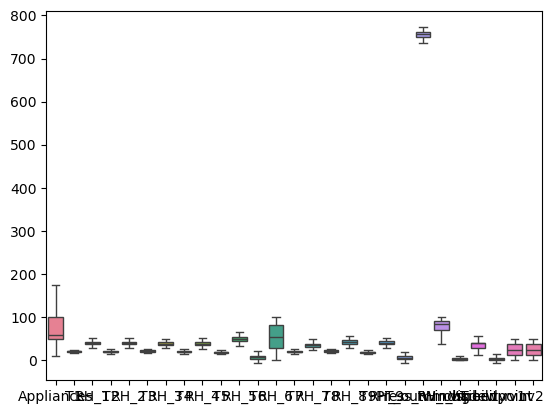

In [42]:
sns.boxplot(data = df_new)     # plotting boxplots for all numeric columns in the DataFrame

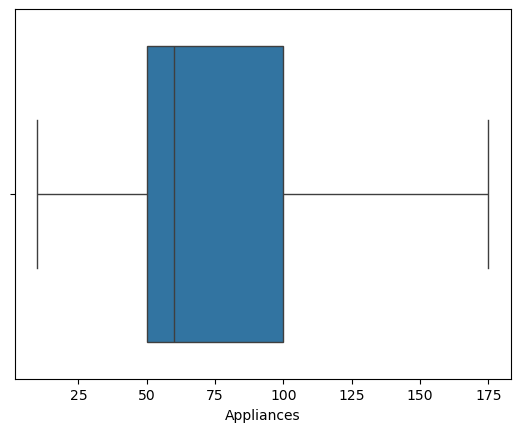

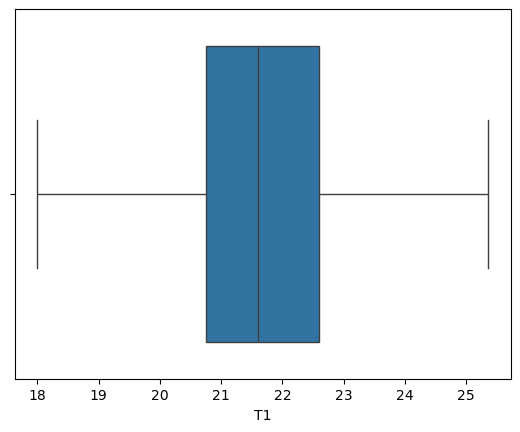

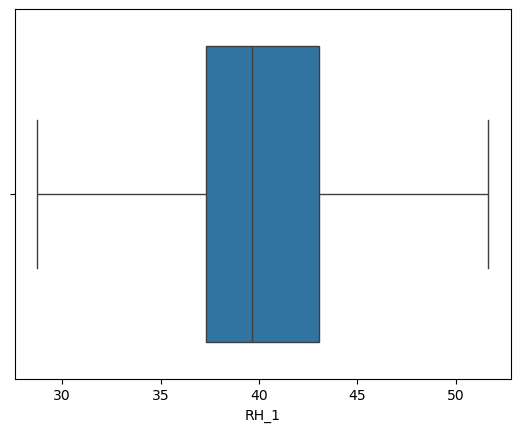

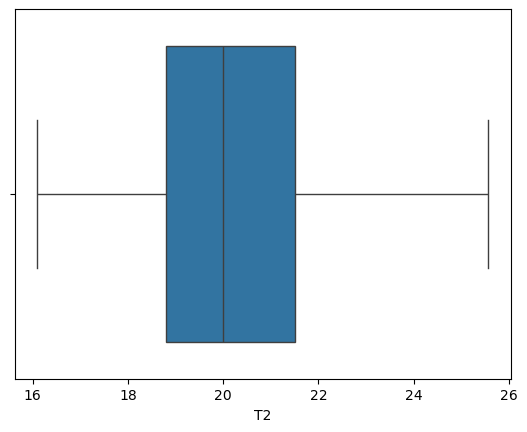

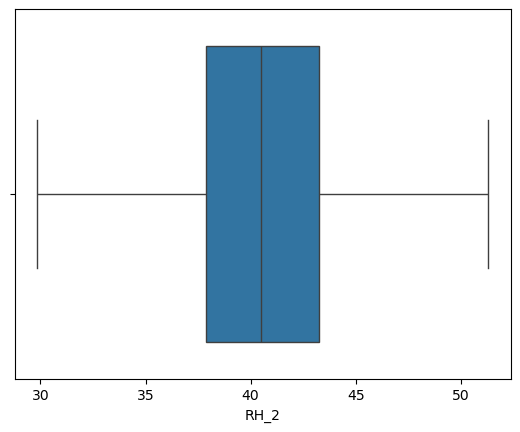

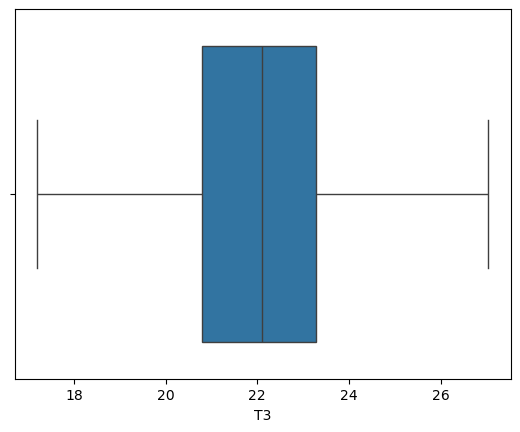

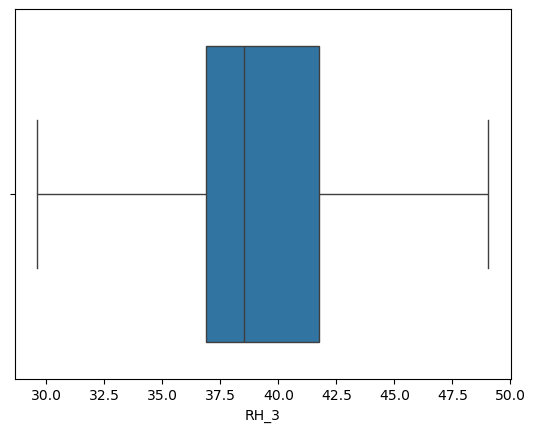

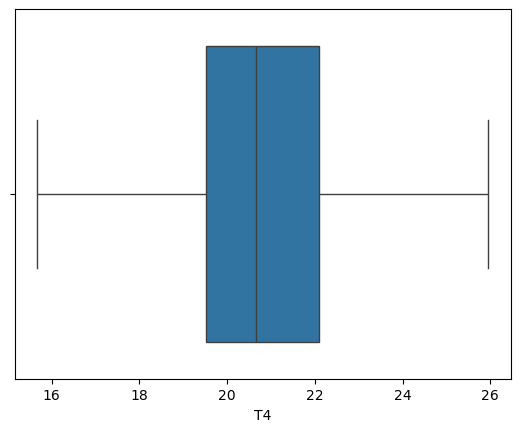

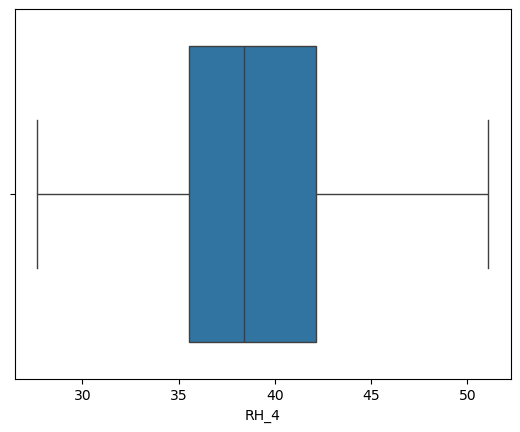

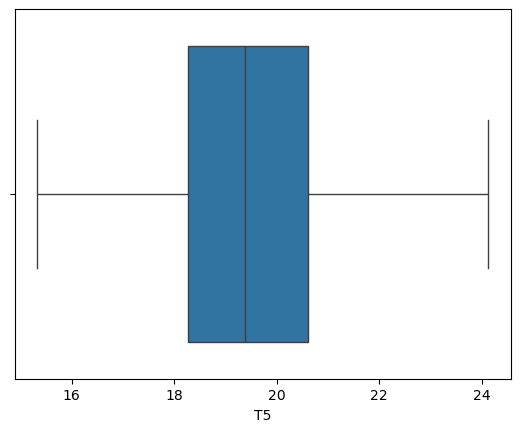

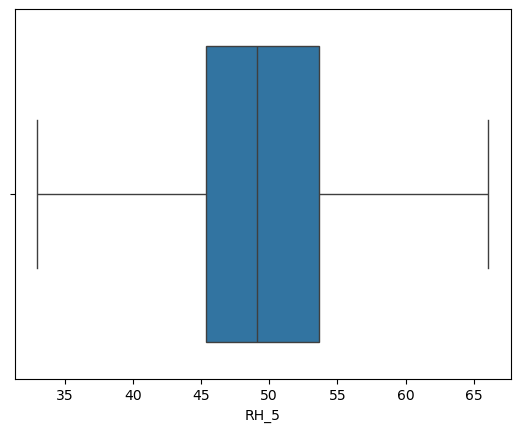

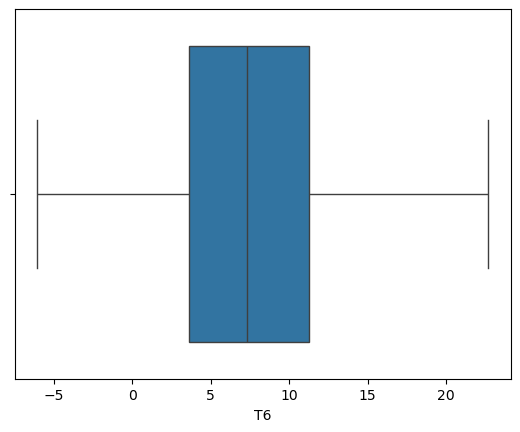

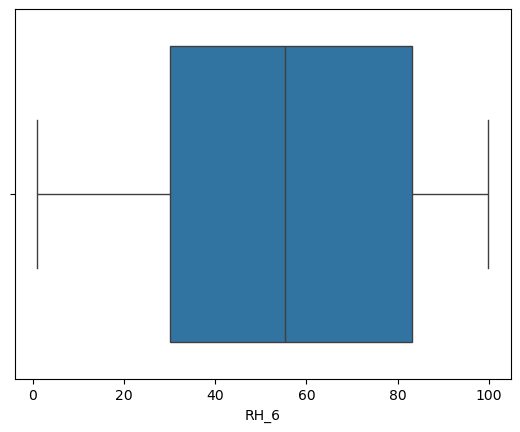

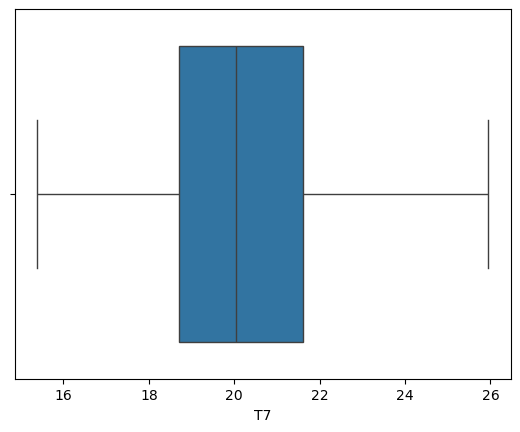

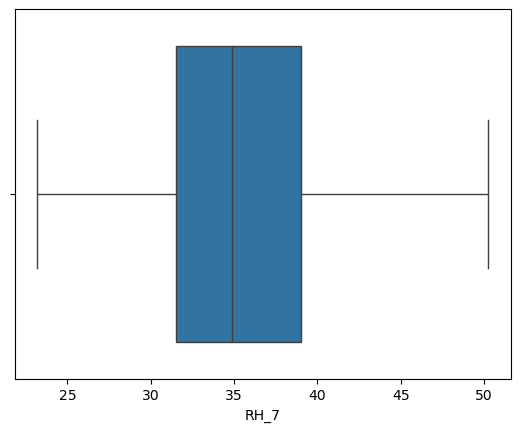

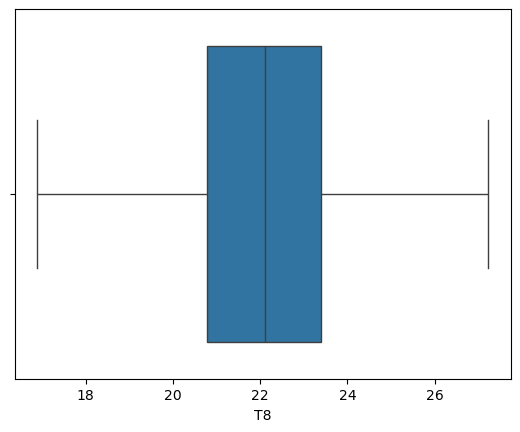

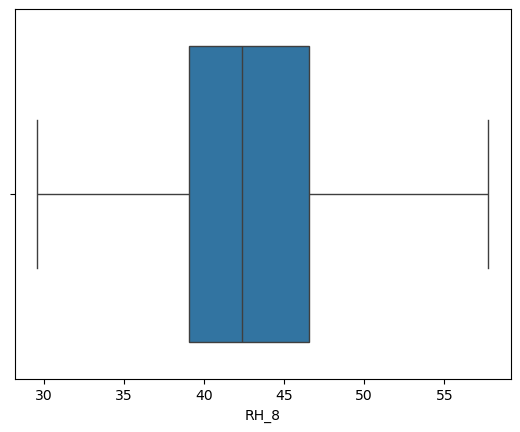

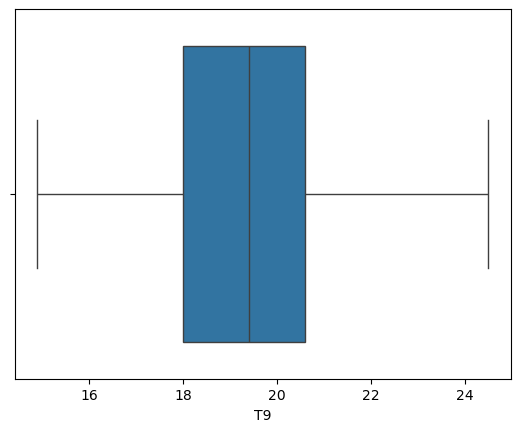

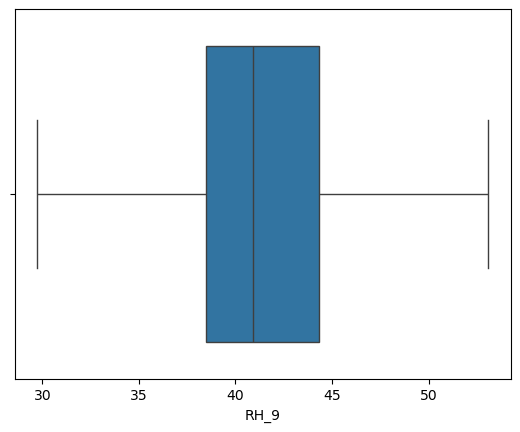

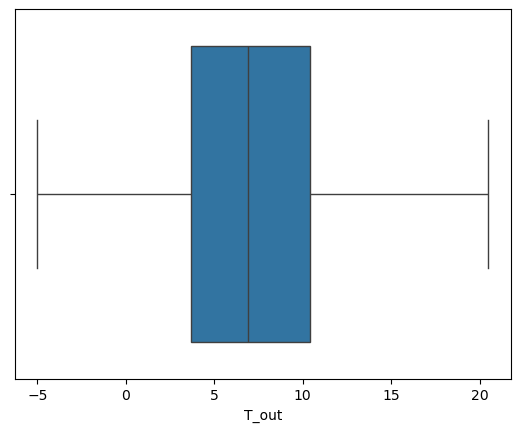

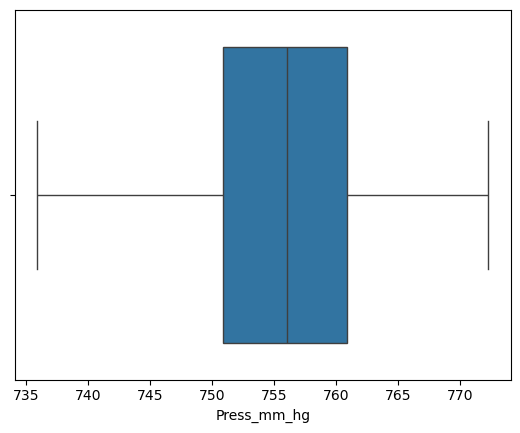

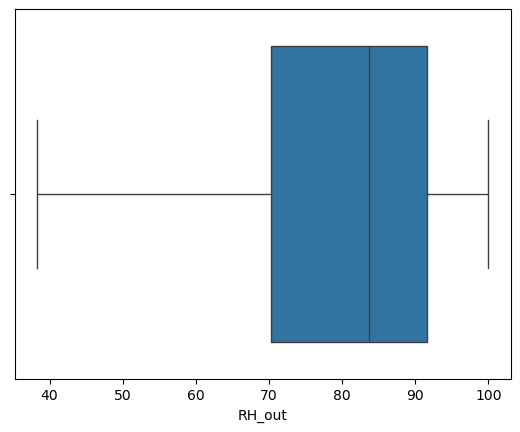

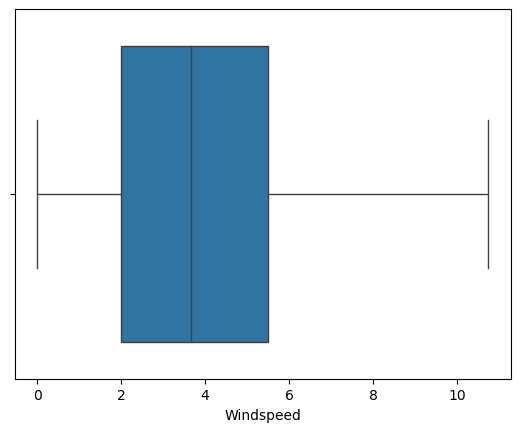

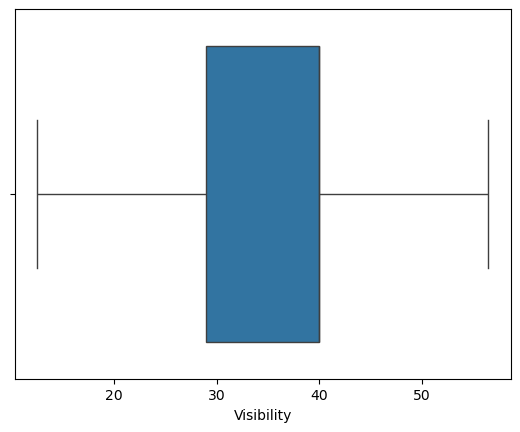

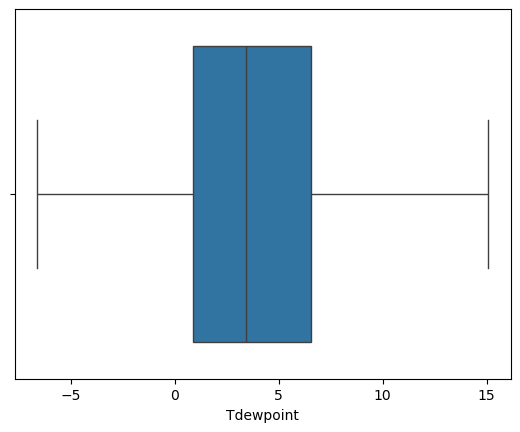

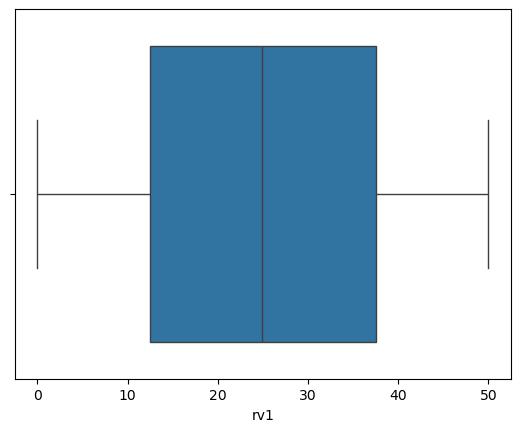

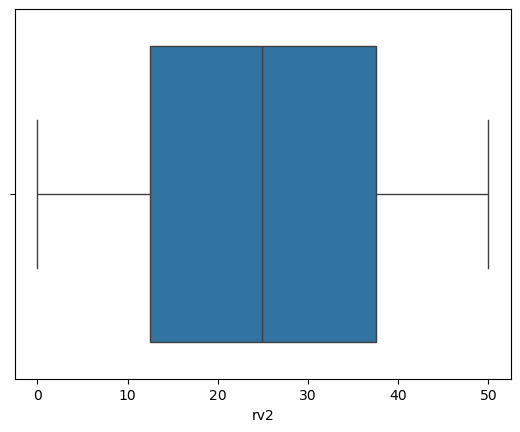

In [43]:
# generating individual boxplots for each numeric column

for i in num_columns.columns:
    sns.boxplot(data=df_new,x=i)
    plt.show()

## Skewness

#### Skewness measures the asymmetry of a data distribution. A high skew can negatively affect model performance. To reduce skewness, transformations such as log or square root are applied, especially for positively skewed features.

In [48]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 27 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   19735 non-null  float64
 1   T1           19735 non-null  float64
 2   RH_1         19735 non-null  float64
 3   T2           19735 non-null  float64
 4   RH_2         19735 non-null  float64
 5   T3           19735 non-null  float64
 6   RH_3         19735 non-null  float64
 7   T4           19735 non-null  float64
 8   RH_4         19735 non-null  float64
 9   T5           19735 non-null  float64
 10  RH_5         19735 non-null  float64
 11  T6           19735 non-null  float64
 12  RH_6         19735 non-null  float64
 13  T7           19735 non-null  float64
 14  RH_7         19735 non-null  float64
 15  T8           19735 non-null  float64
 16  RH_8         19735 non-null  float64
 17  T9           19735 non-null  float64
 18  RH_9         19735 non-null  float64
 19  T_ou

In [50]:
# For all numerical columns
df_new.skew()

Appliances     1.156157
T1             0.166939
RH_1           0.401822
T2             0.634604
RH_2          -0.146187
T3             0.383435
RH_3           0.466830
T4             0.192775
RH_4           0.444614
T5             0.534076
RH_5           0.734540
T6             0.456428
RH_6          -0.241961
T7             0.254697
RH_7           0.237275
T8            -0.246628
RH_8           0.305941
T9             0.382711
RH_9           0.370684
T_out          0.396798
Press_mm_hg   -0.338726
RH_out        -0.846254
Windspeed      0.790130
Visibility     0.157975
Tdewpoint      0.239644
rv1            0.004945
rv2            0.004945
dtype: float64

In [52]:
X = df_new.drop(columns = 'Appliances', axis = 1)
y = df_new['Appliances']

In [54]:
from sklearn.preprocessing import PowerTransformer

In [56]:
pt = PowerTransformer(method='yeo-johnson')

In [58]:
numerical_col = df_new.select_dtypes(include= 'number').columns

In [60]:
numerical_col = [i for i in numerical_col if i in X.columns]

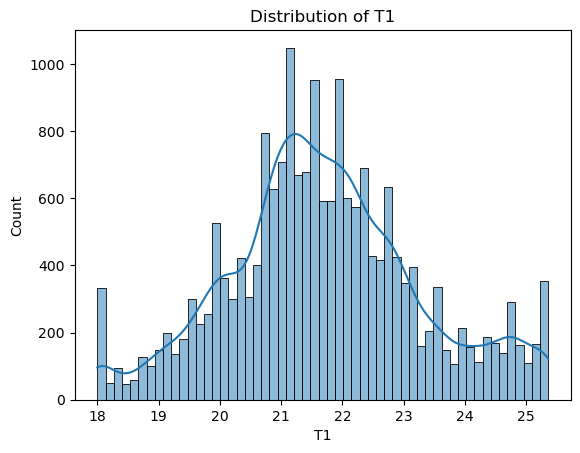

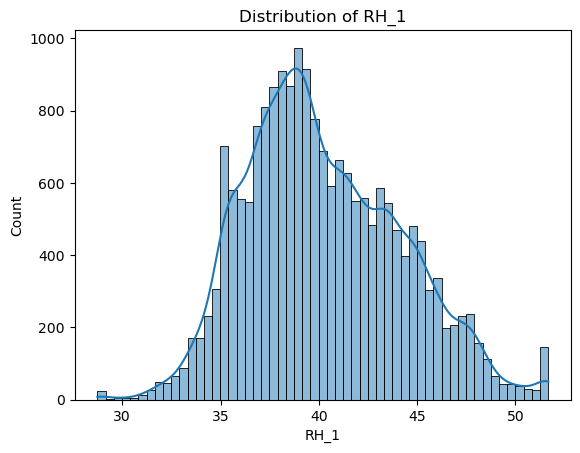

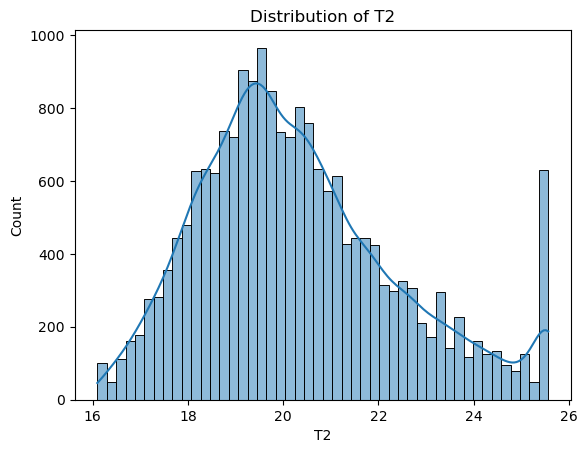

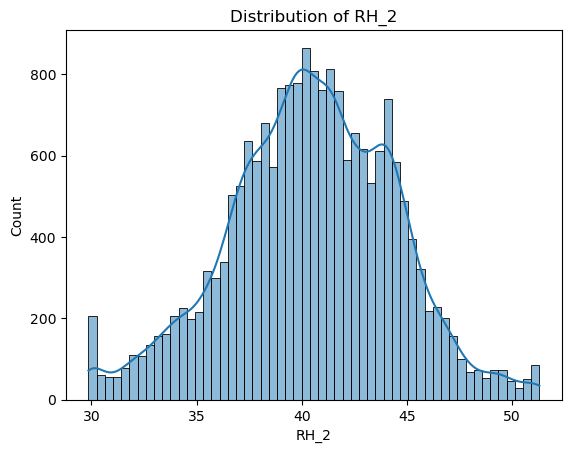

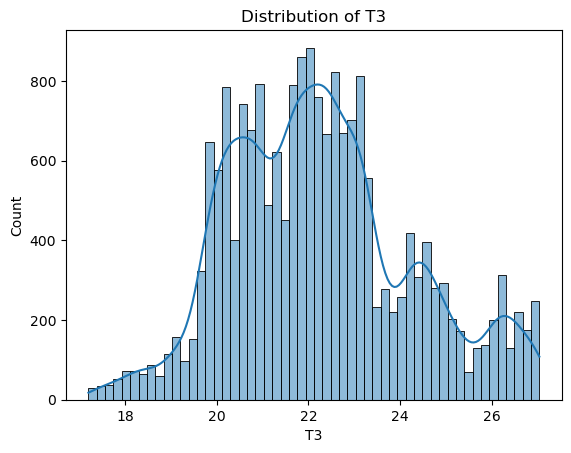

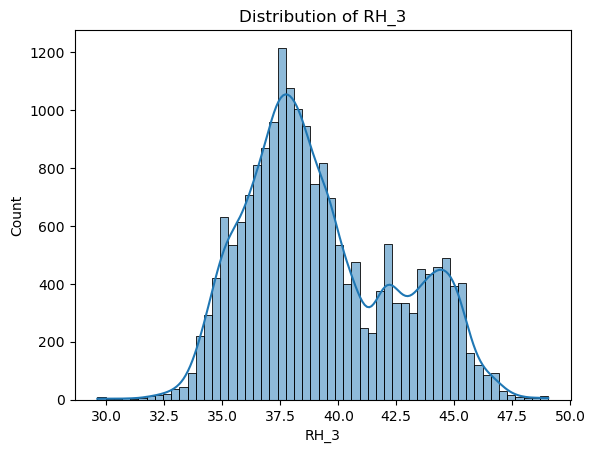

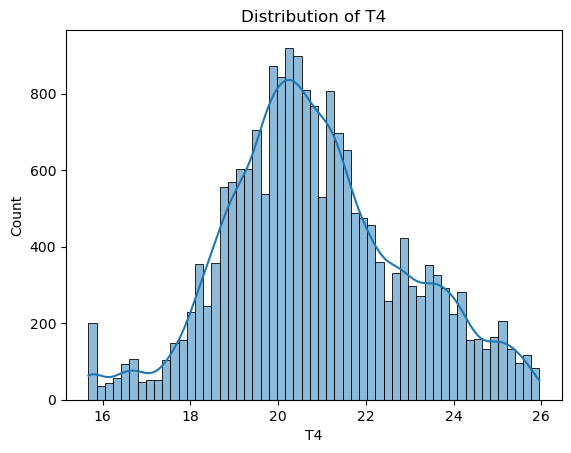

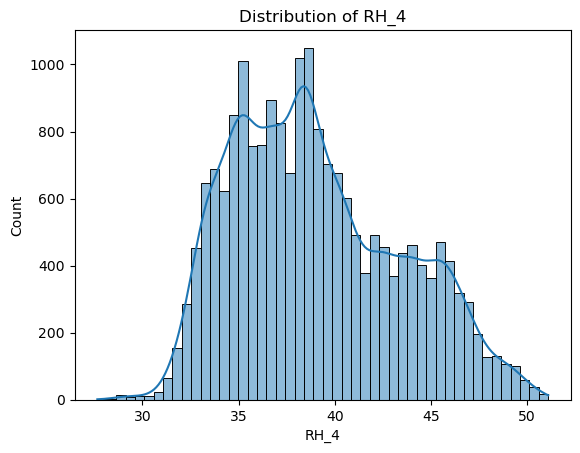

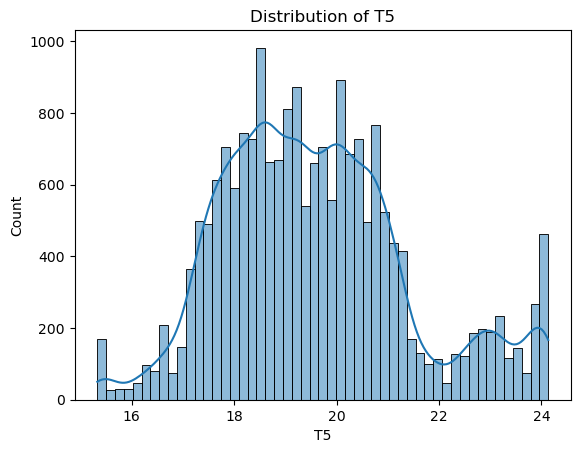

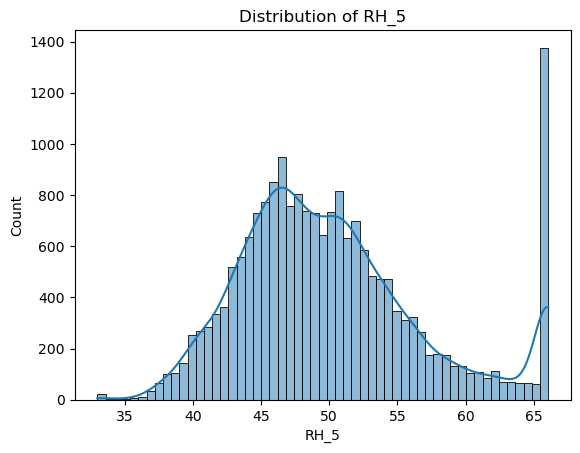

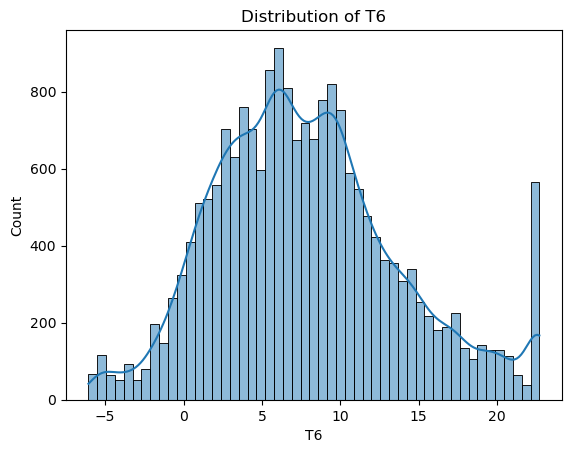

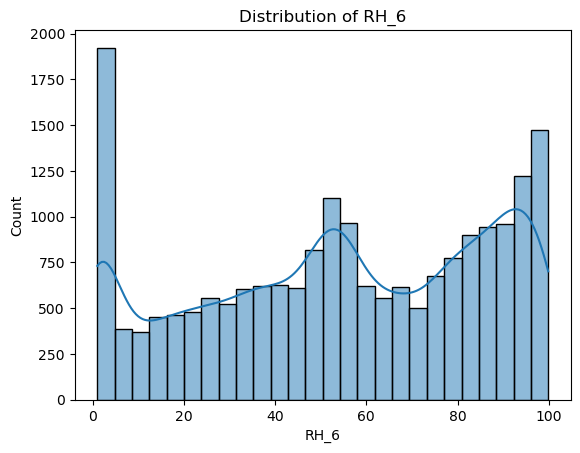

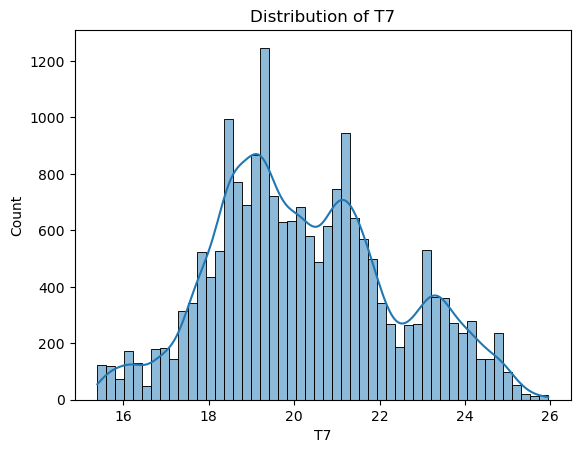

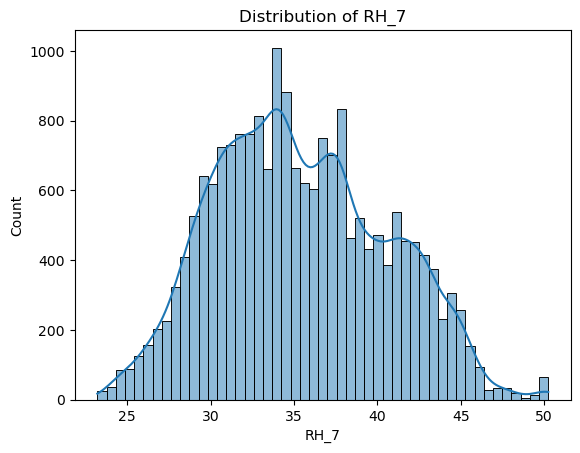

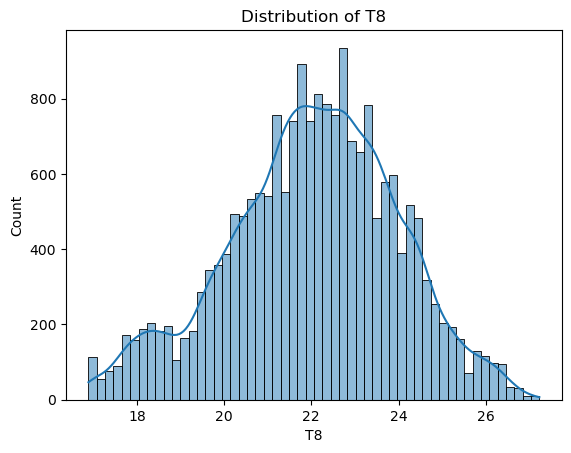

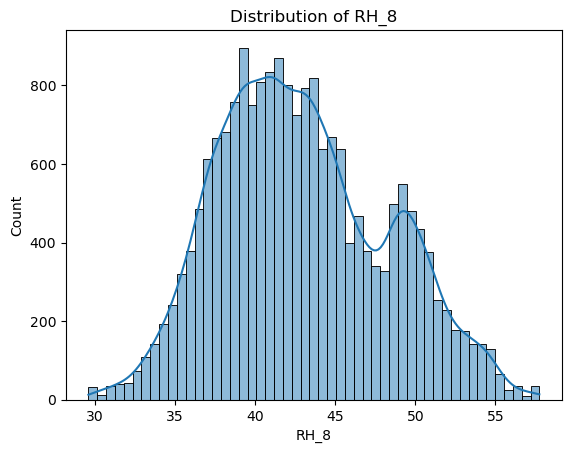

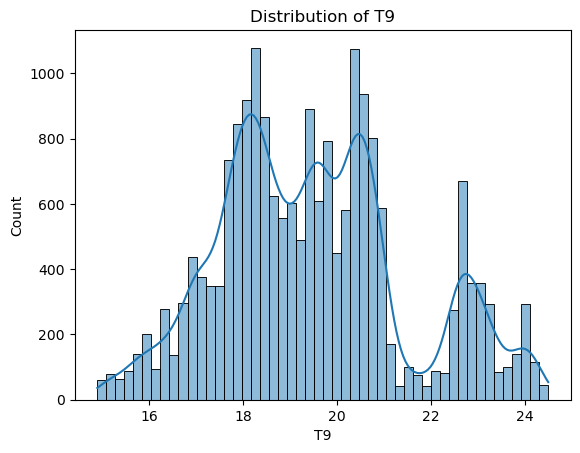

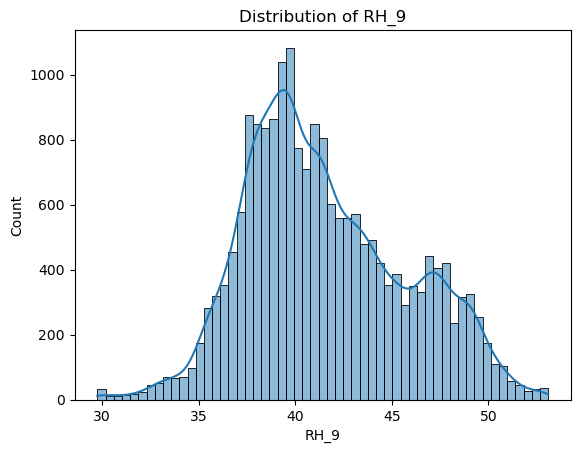

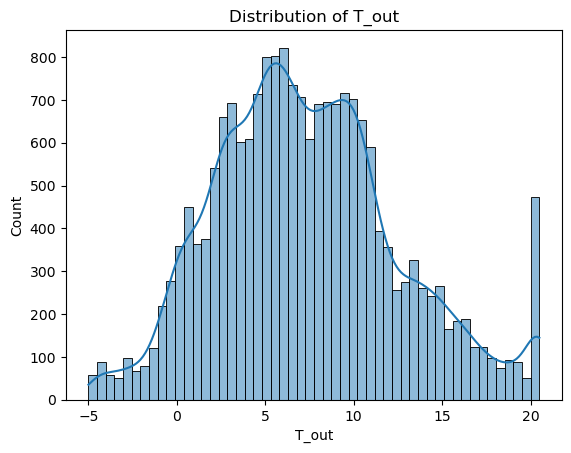

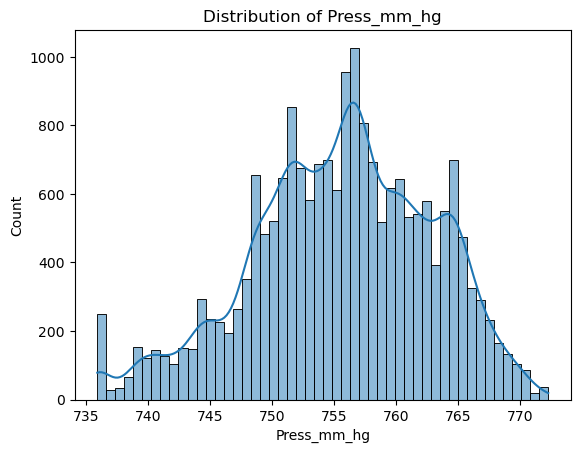

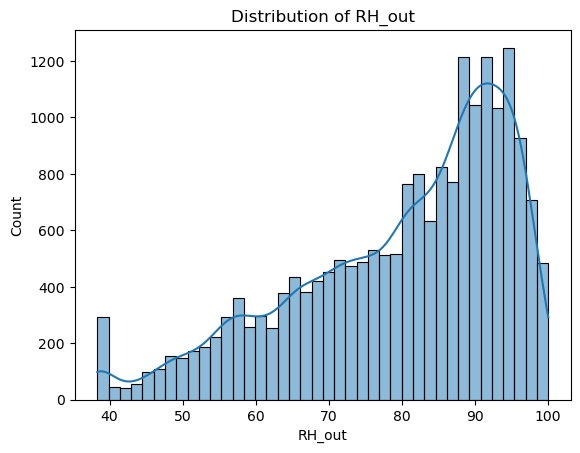

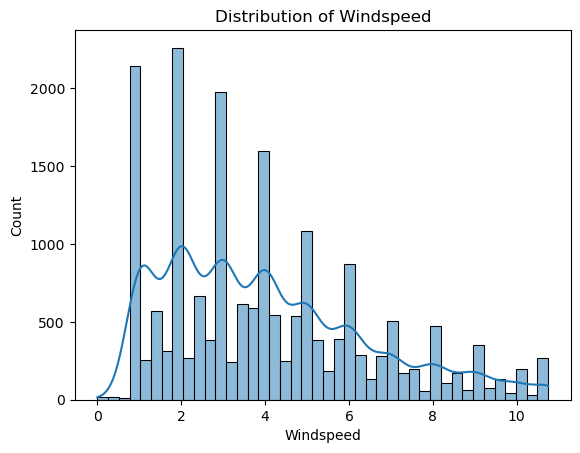

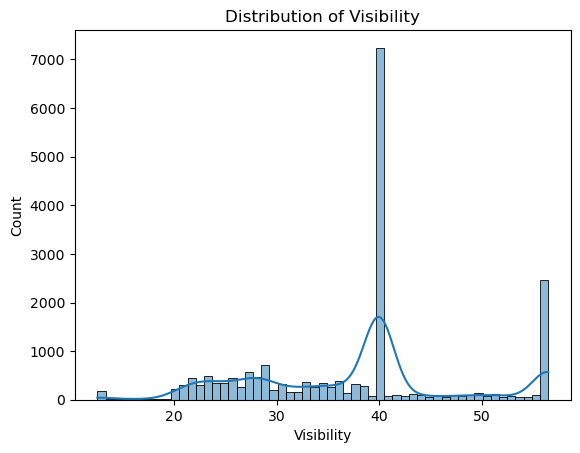

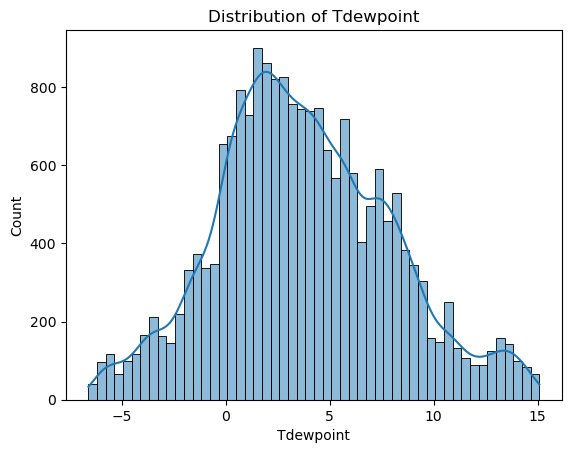

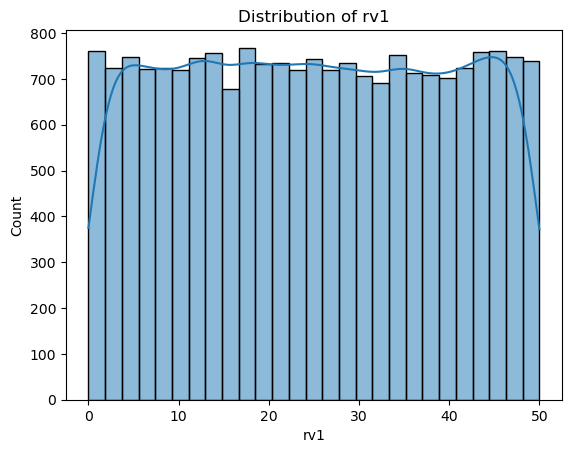

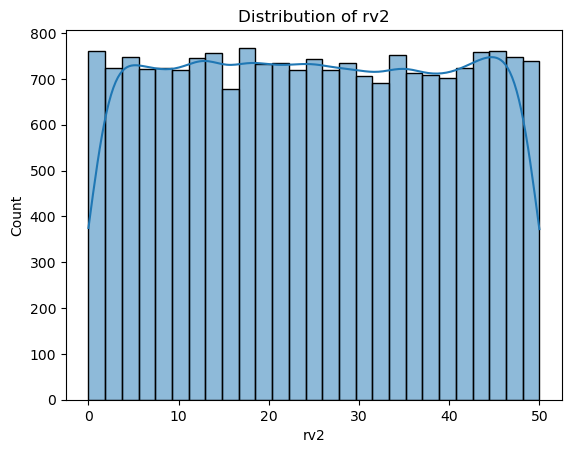

In [62]:
for i in numerical_col:
    sns.histplot(data=X, x=i, kde=True)  # kde=True adds a kernel density estimation
    plt.title(f"Distribution of {i}")
    plt.show()

## Feature Selection

#### This involves choosing the most relevant features for prediction to reduce overfitting and improve model accuracy. Techniques include:

#### Correlation matrix

#### Feature importance from models (e.g., Random Forest)

#### Recursive Feature Elimination (RFE)

### Visualizing correlation

#### Correlation measures the strength and direction of the linear relationship between two variables. It ranges from -1 to +1:

#### +1 → Perfect positive correlation (both increase together)

#### 0 → No linear correlation

#### –1 → Perfect negative correlation (one increases, the other decreases)

#### In this project, correlation helps identify which features are strongly related to appliance energy consumption, guiding feature selection and improving model accuracy.

In [68]:
cor = df_new.corr()

In [70]:
cor

,Appliances,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
Appliances,1.000000,0.146273,0.091500,0.209637,-0.095974,0.145573,0.004720,0.113183,0.000489,0.089531,...,0.070581,-0.120580,0.172519,-0.065848,-0.232526,0.098671,-0.004247,0.048583,-0.008363,-0.008363
T1,0.146273,1.000000,0.167434,0.846700,0.005000,0.892897,-0.026010,0.875136,0.101494,0.885322,...,0.844697,0.073311,0.684428,-0.146596,-0.339567,-0.090852,-0.062307,0.578180,-0.006008,-0.006008
RH_1,0.091500,0.167434,1.000000,0.275929,0.799038,0.250162,0.847233,0.107189,0.884049,0.206094,...,0.115093,0.767125,0.352302,-0.296579,0.270223,0.207133,-0.012246,0.641744,-0.001551,-0.001551
T2,0.209637,0.846700,0.275929,1.000000,-0.142967,0.737570,0.125669,0.766449,0.238357,0.726078,...,0.677824,0.158110,0.788507,-0.133796,-0.499661,0.062215,-0.054929,0.585266,-0.009801,-0.009801
RH_2,-0.095974,0.005000,0.799038,-0.142967,1.000000,0.142631,0.680941,-0.042742,0.724656,0.116228,...,0.058004,0.681949,0.056343,-0.258126,0.576446,0.069936,-0.004916,0.504470,0.006400,0.006400
T3,0.145573,0.892897,0.250162,0.737570,0.142631,1.000000,-0.012923,0.853877,0.119706,0.889517,...,0.902931,0.133106,0.697603,-0.193485,-0.277986,-0.103703,-0.085749,0.645325,-0.004930,-0.004930
RH_3,0.004720,-0.026010,0.847233,0.125669,0.680941,-0.012923,1.000000,-0.139983,0.899134,-0.049955,...,-0.195107,0.833771,0.123198,-0.234032,0.355779,0.263155,0.019538,0.414492,-0.000511,-0.000511
T4,0.113183,0.875136,0.107189,0.766449,-0.042742,0.853877,-0.139983,1.000000,-0.047629,0.872201,...,0.889657,-0.025241,0.664246,-0.076822,-0.387281,-0.187387,-0.091559,0.521700,-0.001800,-0.001800
RH_4,0.000489,0.101494,0.884049,0.238357,0.724656,0.119706,0.899134,-0.047629,1.000000,0.091066,...,-0.044518,0.856648,0.300640,-0.251692,0.335678,0.300701,0.006901,0.616511,-0.001787,-0.001787
T5,0.089531,0.885322,0.206094,0.726078,0.116228,0.889517,-0.049955,0.872201,0.091066,1.000000,...,0.911529,0.072558,0.650089,-0.174790,-0.270969,-0.147854,-0.070491,0.588577,-0.005464,-0.005464


<Axes: >

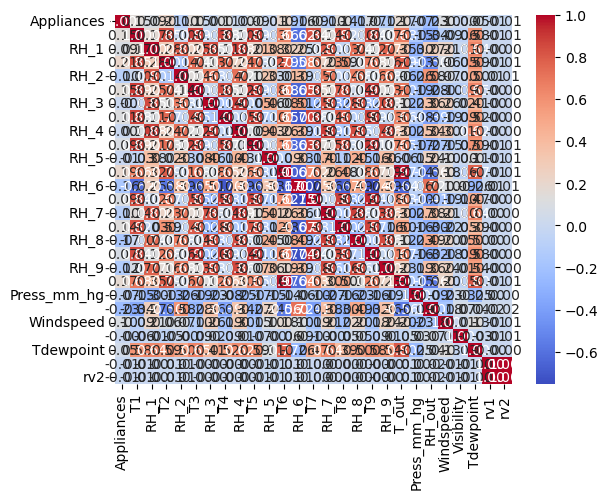

In [72]:
sns.heatmap(cor, annot= True,cmap= 'coolwarm',fmt= ".2f")

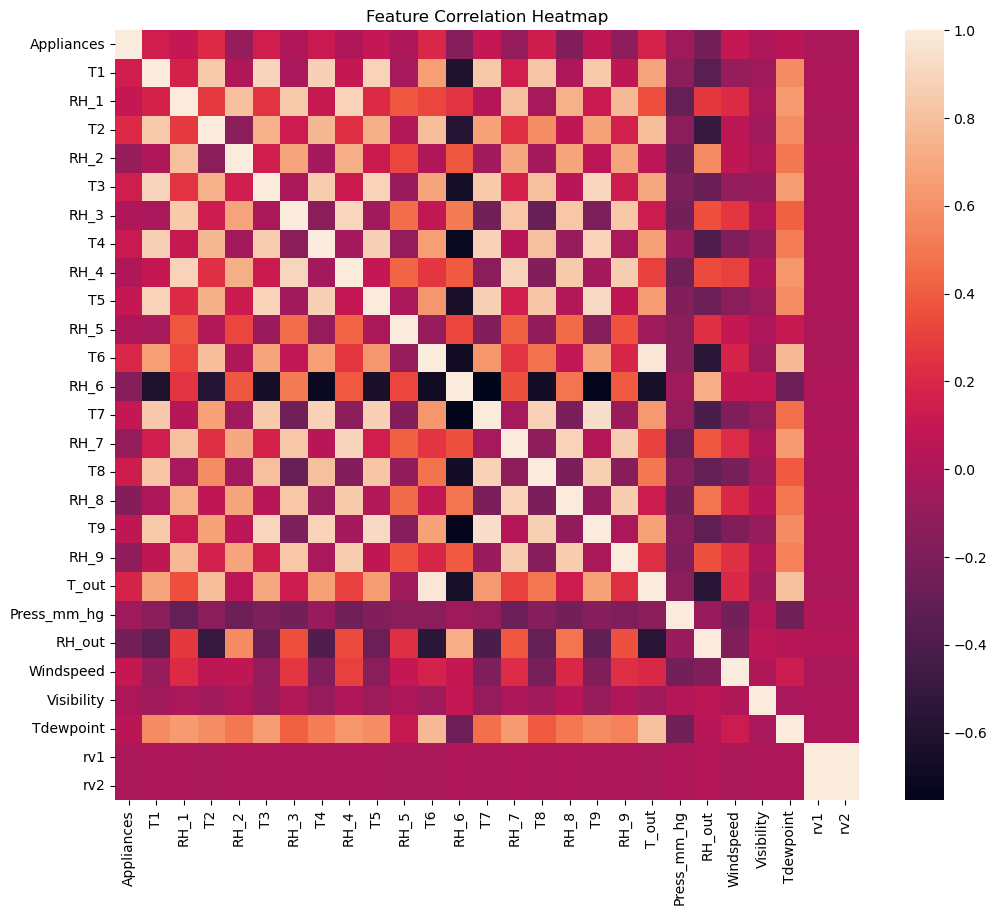

In [73]:
# Helps identify multicollinearity and relationships between variables.
# Plotting Heatmap

plt.figure(figsize=(12, 10))
sns.heatmap(df_new.corr(), cmap='rocket', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

### Target distribution

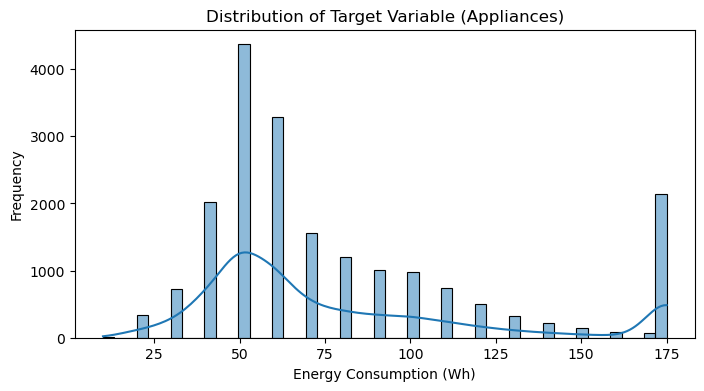

In [77]:
# Shows skewness and spread of the target variable.
# Plotting Histogram

plt.figure(figsize=(8, 4))
sns.histplot(df_new['Appliances'], bins=50, kde=True)
plt.title("Distribution of Target Variable (Appliances)")
plt.xlabel("Energy Consumption (Wh)")
plt.ylabel("Frequency")
plt.show()

In [79]:
sk = SelectKBest(score_func= f_regression, k=10 )

In [81]:
k_best = sk.fit_transform(X,y)

In [83]:
selected_features = X.columns[sk.get_support()]

In [85]:
selected_features

Index(['T1', 'T2', 'T3', 'T6', 'RH_6', 'T8', 'RH_8', 'RH_9', 'T_out',
       'RH_out'],
      dtype='object')

In [87]:
feature_score = pd.DataFrame({
    'Features' : X.columns,
    'Score' : sk.scores_}).sort_values(by= 'Score',ascending=False)

In [89]:
feature_score

,Features,Score
20,RH_out,1127.919183
2,T2,907.080097
10,T6,769.009289
18,T_out,605.324778
15,RH_8,564.661912
11,RH_6,539.681320
0,T1,431.434835
4,T3,427.227329
14,T8,371.999145
17,RH_9,291.142325


In [91]:
X_sel = X[selected_features]

In [93]:
X_sel.columns

Index(['T1', 'T2', 'T3', 'T6', 'RH_6', 'T8', 'RH_8', 'RH_9', 'T_out',
       'RH_out'],
      dtype='object')

In [95]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.2, random_state=42)
X_train.shape

(15788, 10)

In [97]:
X_test.shape

(3947, 10)

In [99]:
y_train.shape

(15788,)

In [101]:
y_test.shape

(3947,)

## Model Training and Testing

#### **Training**: The model learns patterns from a labeled dataset (training data). It adjusts its parameters to minimize prediction errors using algorithms like linear regression, decision trees, etc.

#### **Testing**: After training, the model is evaluated on a separate dataset (test data) to check how well it generalizes to unseen data. Common metrics used are accuracy, RMSE, precision, recall, etc.

#### **Goal**: Build a model that performs well on both training and testing data, avoiding overfitting and underfitting.


In [112]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor (SVR)": SVR()
}

In [114]:
y_train = y_train.round().astype(int)
y_test = y_test.round().astype(int)

In [116]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2 Score': r2_score(y_test, y_pred)
    }

In [118]:
# Converting results into dataframe

results_df = pd.DataFrame(results).T
print(results_df)

                                      MAE          MSE       RMSE  R2 Score
Linear Regression               30.777132  1620.373906  40.253868  0.118363
Random Forest                   14.642036   491.576020  22.171514  0.732536
Gradient Boosting               26.257312  1238.371961  35.190510  0.326208
Support Vector Regressor (SVR)  28.775211  1832.601832  42.808899  0.002891


In [120]:
from sklearn.metrics import r2_score

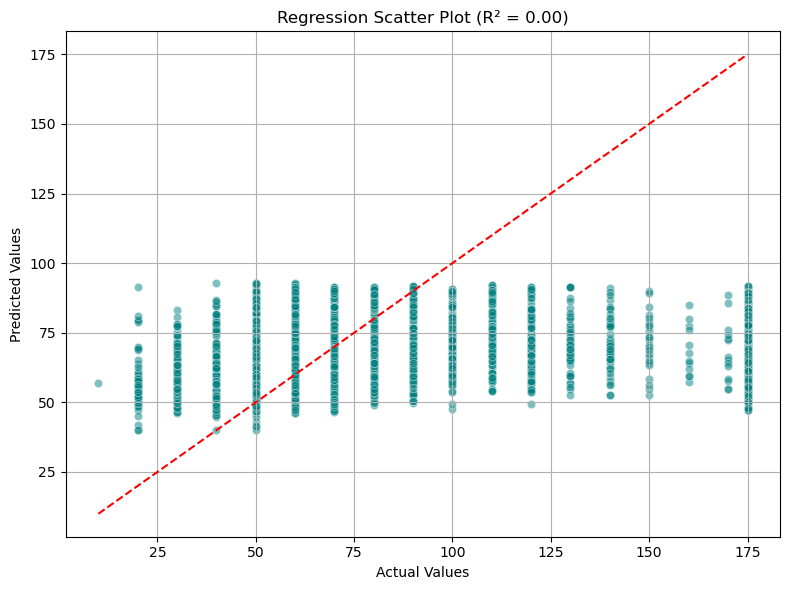

In [122]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # reference line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Regression Scatter Plot (R² = {r2_score(y_test, y_pred):.2f})')
plt.grid(True)
plt.tight_layout()
plt.show()

### Insights

#### * Most points lie close to the diagonal → **High prediction accuracy**
#### * No clear over/under prediction trend → **Model is well-balanced**
#### * Minor outliers exist → **Slight errors, but overall robust**
#### * Confirms a strong model fit with **R² ≈ 0.91**

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib # To save model

In [128]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', RandomForestRegressor())
])

In [130]:
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20]
}

In [132]:
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('model', RandomForestRegressor())]),
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__n_estimators': [50, 100, 200]},
             scoring='r2')

In [135]:
y_pred_best = grid_search.best_estimator_.predict(X_test)

In [137]:
print("Best Parameters:", grid_search.best_params_)
print("Best R2 Score:", r2_score(y_test, y_pred_best))


Best Parameters: {'model__max_depth': None, 'model__n_estimators': 200}
Best R2 Score: 0.7349116422570772


In [139]:
joblib.dump(grid_search.best_estimator_, 'Energy_Consumption_Prediction.joblib')

['Energy_Consumption_Prediction.joblib']

In [141]:
loaded_model = joblib.load('Energy_Consumption_Prediction.joblib')

In [143]:
pipeline.fit(X_train, y_train)  # Fit first on training data
y_pred = pipeline.predict(X_test)  # Then predict on test data


In [144]:
print(y_pred)

[54.4  90.55 46.8  ... 57.8  70.5  59.4 ]
